# Code Comment Classification - Preprocessing

## NLBSE2026 Dataset

### Features:

1. **Data Quality Fix**
   - Fixes `^` → `.` corruption in official dataset
   - Affects: Python 10.9%, Java 1.1%, Pharo 2.6%

2. **Language-Specific Processing**
   - Java: Preserves `@param`, `@return`, `{@link}`
   - Python: Preserves `:param`, `:return`, `#`
   - Pharo: Preserves `:=`, `^`, `#`, `[ ]`, `|`

3. **NEON Sentence Splitting** (Pharo only)
   - Splits on `\n` and structural `:` patterns
   - Preserves message passing syntax (`at:put:`)

4. **Code-Aware Processing**
   - Preserves method calls, URLs, file paths
   - Maintains CamelCase and snake_case

## 1. Setup

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import re
from typing import Dict, List, Tuple
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Configuration
DATA_DIR = Path('dataset')
OUTPUT_DIR = Path('dataset/preprocessed')
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

LANGUAGES = ['java', 'python', 'pharo']
SPLITS = ['train', 'test']

# Label mappings
LABEL_NAMES = {
    'java': ['summary', 'Ownership', 'Expand', 'usage', 'Pointer', 'deprecation', 'rational'],
    'python': ['Usage', 'Parameters', 'DevelopmentNotes', 'Expand', 'Summary'],
    'pharo': ['Keyimplementationpoints', 'Example', 'Responsibilities', 'Intent', 'Keymessages', 'Collaborators']
}

print(f"Data directory: {DATA_DIR.resolve()}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")
print(f"\nLanguages: {LANGUAGES}")
print(f"Label counts: Java={len(LABEL_NAMES['java'])}, Python={len(LABEL_NAMES['python'])}, Pharo={len(LABEL_NAMES['pharo'])}")

Data directory: /home/aizen/Code/ccc/dataset
Output directory: /home/aizen/Code/ccc/dataset/preprocessed

Languages: ['java', 'python', 'pharo']
Label counts: Java=7, Python=5, Pharo=6


## 2. Preprocessing Functions

Language-specific preprocessing with caret corruption fix.

In [2]:
def fix_caret_corruption(text: str, language: str) -> str:
    """
    Fix ^ → . corruption in the dataset.
    
    Args:
        text: Comment text to fix
        language: 'java', 'python', or 'pharo'
        
    Returns:
        Fixed text with ^ replaced by . where appropriate
    """
    if not isinstance(text, str) or not text.strip():
        return text
    
    if language in ['python', 'java']:
        # For Python and Java: Replace ALL ^ with .
        return text.replace('^', '.')
    
    elif language == 'pharo':
        # For Pharo: Be conservative - some ^ are legitimate return operators
        # Only fix obvious corruption patterns
        
        # Pattern 1: URLs (www^domain^com, http^example^com)
        # Fix: Replace all ^ in URL contexts
        text = re.sub(r'((?:www|http|https)[^\s]*)\^', lambda m: m.group(1) + '.', text)
        
        # Pattern 2: File extensions (filename^txt, config^json, etc.)
        text = re.sub(r'(\w{3,})\^(txt|json|conf|xml|html|py|js|css|png|jpg|gif|pillar|mustache)', r'\1.\2', text, flags=re.IGNORECASE)
        
        # Pattern 3: Multi-segment paths (word^word^word with 3+ segments)
        text = re.sub(r'(\w+\^\w+\^\w+)', lambda m: m.group(0).replace('^', '.'), text)
        
        # DON'T replace:
        # - "^ " (return operator with space) - left unchanged
        # - "x^2" (math exponent notation) - left unchanged  
        # - "^^" (double caret math) - left unchanged
        
        return text
    
    return text


In [3]:
def preprocess_java(text: str) -> str:
    """
    Java-specific preprocessing.
    Preserves: @param, @return, @throws, @see, @deprecated, <code>, {@link}, etc.
    Removes: /* */ /** comment markers
    """
    if not isinstance(text, str) or not text.strip():
        return ''

    # FIX: Apply caret corruption fix FIRST
    text = fix_caret_corruption(text, 'java')

    # Remove Java comment markers but keep content
    text = re.sub(r'/\*+', '', text)  # Remove /* and /** (FIX: was only /**)
    text = re.sub(r'\*/', '', text)     # Remove */
    text = re.sub(r'^\s*\*\s?', '', text, flags=re.MULTILINE)  # Remove leading * on lines
    text = re.sub(r'^\s*//', '', text, flags=re.MULTILINE)     # Remove //

    # Preserve JavaDoc tags by adding space around them
    text = re.sub(r'@(param|return|throws|see|deprecated|author|since|version)', r' @\1 ', text)

    # Preserve HTML/XML tags common in JavaDoc
    text = re.sub(r'<(p|code|pre|br|li|ul|ol)>', r' <\1> ', text, flags=re.IGNORECASE)
    text = re.sub(r'</(p|code|pre|br|li|ul|ol)>', r' </\1> ', text, flags=re.IGNORECASE)

    # Preserve {@link} and {@code}
    text = re.sub(r'\{@(link|code|value)', r' {@\1 ', text)

    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text)
    result = text.strip().lower()

    # Safety check: if preprocessing removed all content, return empty string
    if not result:
        return ''

    return result


def preprocess_python(text: str) -> str:
    """
    Python-specific preprocessing.
    Preserves: :param, :type, :return, :raises, # comments, docstring structure
    """
    if not isinstance(text, str) or not text.strip():
        return ''
    
    # FIX: Apply caret corruption fix FIRST
    text = fix_caret_corruption(text, 'python')
    
    # Remove docstring quotes but keep content (FIX: {3} not {{3}})
    text = re.sub(r'^[\'\"]{3}|[\'\"]{3}$', '', text)  # Remove """ or '''
    
    # Preserve reStructuredText/Sphinx tags
    text = re.sub(r':(param|type|return|rtype|raises|note|warning|example)', r' :\1 ', text)
    
    # Keep # for comments (common in Python docs)
    text = re.sub(r'#', ' # ', text)
    
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip().lower()


def preprocess_pharo(text: str) -> str:
    """
    Pharo/Smalltalk-specific preprocessing with NEON sentence splitting.
    
    CRITICAL: Pharo is an OOD challenge - different syntax from Java/Python.
    
    Uses NEON splitting strategy (NLBSE'23/24 baseline):
    - Split on newline (\n) or colon (:) as sentence boundaries for STRUCTURED comments
    - Preserves message passing syntax (e.g., at:put:) by protecting keyword selectors
    
    Preserves:
    - := (assignment)
    - ^ (return)
    - # (symbol literal)
    - [ ] (blocks/closures)
    - | | (temporary variables)
    - Message passing syntax (at:put:, do:, etc.)
    """
    if not isinstance(text, str) or not text.strip():
        return ''
    
    # FIX: Apply caret corruption fix FIRST
    text = fix_caret_corruption(text, 'pharo')
    
    # Remove Pharo comment markers but keep content
    text = text.strip()
    if text.startswith('"') and text.endswith('"'):
        text = text[1:-1].strip()
    
    # FIX: Improved protection for Pharo syntax
    # 1. Protect assignment :=
    text = text.replace(':=', '__ASSIGN__')
    
    # 2. Protect block arguments and parameters (e.g., [:x | x + 1])
    # This protects the entire block expression
    text = re.sub(r'\[\s*:(\w+(?:\s+:\w+)*)\s*\|', r'[ __BLOCKARG__\1 |', text)
    
    # 3. Protect message selectors (keyword messages like at:put:, do:, etc.)
    # Pattern: word followed by colon not followed by whitespace and capital letter
    # This protects "self at: key" but allows "Intent: Do something" to split
    text = re.sub(r'(\w+):\s+(?![A-Z])', r'\1__COLON__ ', text)
    
    # NEON-style splitting: Split on \n or : (as used in NLBSE competitions)
    # Only split on structural colons like "Intent: ..." or "Responsibilities: ..."
    # The >= 2 threshold is removed - we now rely on protection mechanism
    if '\n' in text or (':' in text and re.search(r':\s+[A-Z]', text)):
        # Split on newline or colon followed by space and capital letter (structured comments)
        sentences = re.split(r'[\n]|:\s+(?=[A-Z])', text)
        # Filter empty, rejoin with period for better tokenization
        sentences = [s.strip() for s in sentences if s.strip()]
        text = '. '.join(sentences)
    
    # Restore protected tokens
    text = text.replace('__ASSIGN__', ':=')
    text = re.sub(r'__BLOCKARG__', ':', text)
    text = re.sub(r'__COLON__', ':', text)
    
    # Space Pharo-specific operators for better tokenization
    # This helps the tokenizer recognize them as distinct units
    text = re.sub(r':=', ' := ', text)  # Assignment
    text = re.sub(r'\^', ' ^ ', text)    # Return
    text = re.sub(r'#(\w+)', r' # \1 ', text)  # Symbol literals
    text = re.sub(r'\[', ' [ ', text)    # Block start
    text = re.sub(r'\]', ' ] ', text)    # Block end
    text = re.sub(r'\|', ' | ', text)    # Temporary variables
    
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip().lower()


def split_sentences_code_aware(text: str) -> List[str]:
    """
    Split text into sentences while respecting code boundaries.
    
    CRITICAL: Standard NLP sentence splitters (like NLTK) will incorrectly 
    split on periods inside code (e.g., self.method, file.txt, URLs).
    
    This function protects:
    - Method calls: self.method, Class.field
    - URLs: http://example.com (FIX: now properly handled by not converting)
    - File paths: file.txt
    - Decimal numbers: 1.5, 3.14
    
    Splits on:
    - Period/exclamation/question mark followed by space and capital letter
    - End of text
    
    NOTE: For Pharo, NEON splitting (\n|:) is used in preprocess_pharo() instead.
    """
    if not isinstance(text, str) or not text.strip():
        return []
    
    # Already a single sentence (most common case)
    # If no sentence-ending punctuation followed by more text, return as-is
    if not re.search(r'[.!?]\s+[A-Z]', text) and not re.search(r'[.!?]\s*$', text):
        return [text.strip()]
    
    # FIX: Don't convert URLs - just protect method calls and numbers
    # URLs will be naturally protected because they don't match the split pattern
    
    # Protect method/property access: word.word (no space)
    protected = []
    
    def protect(match):
        protected.append(match.group(0))
        return f"__PROTECTED_{len(protected)-1}__"
    
    # Only protect method/field access and decimal numbers
    # URLs are naturally safe because http://example.com doesn't match word.word pattern
    text = re.sub(r'(?<!\w)\w+\.\w+(?!\w)', protect, text)  # Method/field access
    text = re.sub(r'\d+\.\d+', protect, text)  # Decimal numbers
    
    # Split on sentence boundaries: [.!?] followed by space/newline
    sentences = re.split(r'[.!?]+(?:\s+|$)', text)
    
    # Restore protected patterns and clean up
    result = []
    for sent in sentences:
        sent = sent.strip()
        if sent:
            # Restore all protected patterns
            for i, protected_text in enumerate(protected):
                sent = sent.replace(f"__PROTECTED_{i}__", protected_text)
            result.append(sent)
    
    return result if result else [text.strip()]


def clean_comment(text: str, language: str) -> str:
    """
    Main preprocessing function - dispatches to language-specific handlers.
    """
    if language == 'java':
        return preprocess_java(text)
    elif language == 'python':
        return preprocess_python(text)
    elif language == 'pharo':
        return preprocess_pharo(text)
    else:
        # Fallback: just normalize whitespace
        if not isinstance(text, str):
            return ''
        return re.sub(r'\s+', ' ', text).strip().lower()


print("Language-specific preprocessing functions defined")

Language-specific preprocessing functions defined


## 3. Load and Preprocess Data

Load datasets and apply language-specific preprocessing.

In [4]:
# Load all datasets
datasets = {}
stats = []

print("Loading and preprocessing datasets...")

for lang in LANGUAGES:
    for split in SPLITS:
        filename = f"{lang}_{split}.parquet"
        filepath = DATA_DIR / filename
        
        if not filepath.exists():
            print(f"⚠️  File not found: {filepath}")
            continue
        
        df = pd.read_parquet(filepath)
        df['language'] = lang
        df['split'] = split
        
        # Apply preprocessing
        df['comment_clean'] = df.apply(
            lambda row: clean_comment(row['comment_sentence'], lang), 
            axis=1
        )
        
        # Replace empty preprocessed comments with 'empty' keyword
        empty_mask = df['comment_clean'] == ''
        df.loc[empty_mask, 'comment_clean'] = 'empty'
        
        df['combo_clean'] = df['class'] + ' | ' + df['comment_clean']
        
        # Statistics
        orig_words = df['comment_sentence'].str.split().str.len()
        clean_words = df['comment_clean'].str.split().str.len()
        
        stats.append({
            'language': lang,
            'split': split,
            'samples': len(df),
            'avg_words_orig': f"{orig_words.mean():.1f}",
            'avg_words_clean': f"{clean_words.mean():.1f}",
            'empty_after': (df['comment_clean'] == '').sum(),
        })
        
        datasets[f"{lang}_{split}"] = df
        print(f"✓ {lang}_{split}: {len(df)} samples")

print("\nStatistics:")
print(pd.DataFrame(stats).to_string(index=False))

Loading and preprocessing datasets...
✓ java_train: 5394 samples
✓ java_test: 1201 samples
✓ python_train: 1368 samples
✓ python_test: 290 samples
✓ pharo_train: 900 samples
✓ pharo_test: 208 samples

Statistics:
language split  samples avg_words_orig avg_words_clean  empty_after
    java train     5394           10.6             9.6            0
    java  test     1201           12.7            11.5            0
  python train     1368            7.0             7.0            0
  python  test      290            7.7             7.7            0
   pharo train      900            9.1             9.4            0
   pharo  test      208            8.6             8.8            0


In [5]:
# Detailed Keyword Preservation Analysis
print("\n" + "="*80)
print("Detailed Keyword Preservation Analysis (Original vs Cleaned)")
print("="*80)

# Create all_data if not exists
if 'all_data' not in locals():
    all_data = pd.concat(datasets.values(), ignore_index=True)

# Define keywords to track per language
keywords_to_track = {
    'java': ['@param', '@return', '@throws', '<code>', '{@link}', 'TODO', 'null', 'true', 'false'],
    'python': [':param', ':return', ':type', ':raises', '>>>', 'self', 'None', 'True', 'False'],
    'pharo': [':=', '^', '#', '[', ']', '|', 'self', 'super', 'true', 'false', 'nil']
}

for lang in LANGUAGES:
    if lang not in keywords_to_track:
        continue
        
    print(f"\n{lang.upper()} Analysis:")
    print(f"{'Keyword':<15} {'Original (Count)':<20} {'Cleaned (Count)':<20} {'Retention'}")
    print("-" * 70)
    
    # Get data for language
    df = all_data[all_data['language'] == lang]
    
    for kw in keywords_to_track[lang]:
        orig_count = df['comment_sentence'].str.count(re.escape(kw)).sum()
        clean_kw = kw.lower()
        clean_count = df['comment_clean'].str.count(re.escape(clean_kw)).sum()
        retention = f"{clean_count/orig_count*100:.1f}%" if orig_count > 0 else "N/A"
        print(f"{kw:<15} {orig_count:<20} {clean_count:<20} {retention}")


Detailed Keyword Preservation Analysis (Original vs Cleaned)

JAVA Analysis:
Keyword         Original (Count)     Cleaned (Count)      Retention
----------------------------------------------------------------------
@param          874                  874                  100.0%
@return         437                  437                  100.0%
@throws         38                   38                   100.0%
<code>          204                  204                  100.0%
{@link}         0                    0                    N/A
TODO            0                    2                    N/A
null            152                  157                  103.3%
true            111                  118                  106.3%
false           57                   57                   100.0%

PYTHON Analysis:
Keyword         Original (Count)     Cleaned (Count)      Retention
----------------------------------------------------------------------
:param          0                    0         

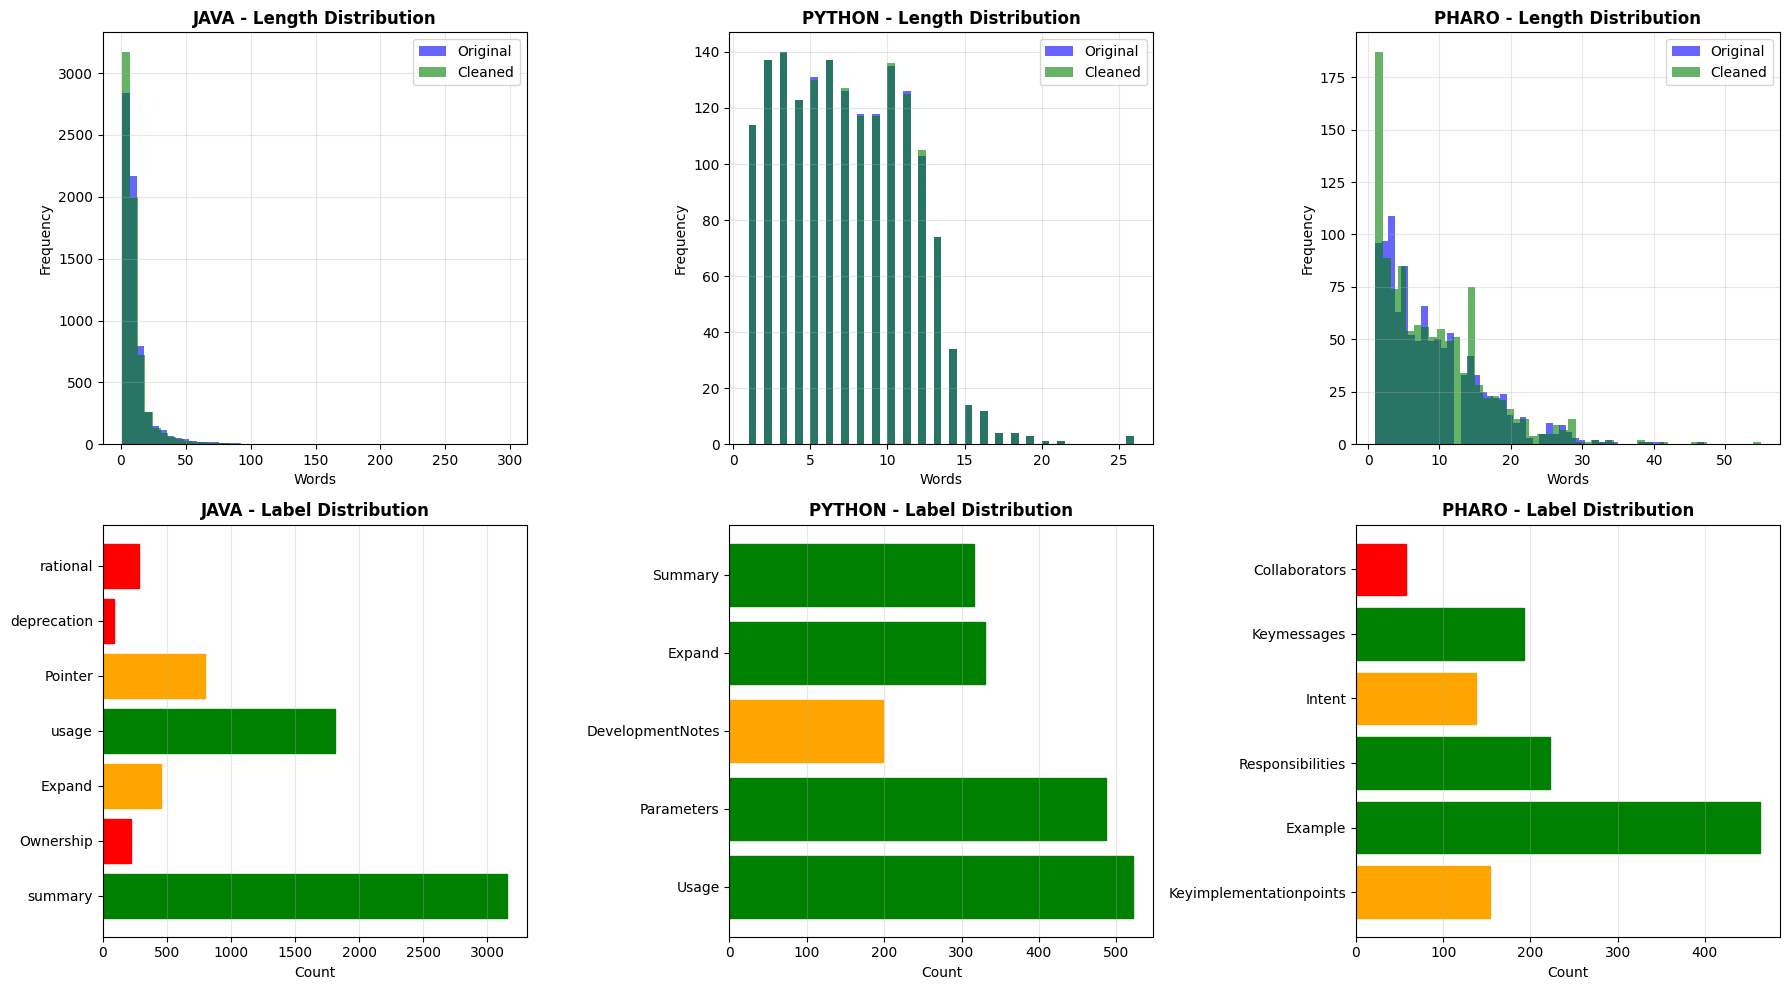


✓ Saved visualization to dataset/preprocessed/preprocessing_analysis.png


In [6]:
# Calculate lengths
all_data['orig_len'] = all_data['comment_sentence'].str.split().str.len()
all_data['clean_len'] = all_data['comment_clean'].str.split().str.len()

# Plot
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, lang in enumerate(LANGUAGES):
    lang_data = all_data[all_data['language'] == lang]
    
    # Length distribution
    ax = axes[0, idx]
    ax.hist(lang_data['orig_len'], bins=50, alpha=0.6, label='Original', color='blue')
    ax.hist(lang_data['clean_len'], bins=50, alpha=0.6, label='Cleaned', color='green')
    ax.set_title(f'{lang.upper()} - Length Distribution', fontweight='bold')
    ax.set_xlabel('Words')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Label distribution
    ax = axes[1, idx]
    labels = LABEL_NAMES[lang]
    label_counts = []
    for i in range(len(labels)):
        count = sum(row['labels'][i] == 1 for _, row in lang_data.iterrows() if i < len(row['labels']))
        label_counts.append(count)
    
    bars = ax.barh(labels, label_counts)
    # Color code by frequency
    total = sum(label_counts)
    for bar, count in zip(bars, label_counts):
        freq = count / total * 100
        if freq < 5:
            bar.set_color('red')
        elif freq < 15:
            bar.set_color('orange')
        else:
            bar.set_color('green')
    
    ax.set_title(f'{lang.upper()} - Label Distribution', fontweight='bold')
    ax.set_xlabel('Count')
    ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'preprocessing_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved visualization to {OUTPUT_DIR / 'preprocessing_analysis.png'}")

In [7]:
def labels_to_names(labels_array, lang):
    """Convert binary label array to category names."""
    if labels_array is None or not isinstance(labels_array, (list, np.ndarray)):
        return []
    label_names = LABEL_NAMES[lang]
    return [label_names[i] for i, val in enumerate(labels_array) if i < len(label_names) and val == 1]

# Create inspection DataFrames
for lang in LANGUAGES:
    for split in SPLITS:
        df = datasets[f'{lang}_{split}']
        inspect_df = pd.DataFrame({
            'index': df['index'],
            'class_name': df['class'],
            'original_comment': df['comment_sentence'],
            'preprocessed_comment': df['comment_clean'],
            'categories': df.apply(lambda row: labels_to_names(row['labels'], lang), axis=1)
        })
        inspect_df.to_csv(OUTPUT_DIR / f'inspect_{lang}_{split}.csv', index=False)
        print(f"✓ {lang}_{split}: {len(inspect_df)} rows")

print(f"\nExported to: {OUTPUT_DIR}/inspect_*.csv")

✓ java_train: 5394 rows
✓ java_test: 1201 rows
✓ python_train: 1368 rows
✓ python_test: 290 rows
✓ pharo_train: 900 rows
✓ pharo_test: 208 rows

Exported to: dataset/preprocessed/inspect_*.csv


In [9]:
print("\n" + "="*80)
print("Saving Preprocessed Datasets")
print("="*80)

for key, df in datasets.items():
    output_path = OUTPUT_DIR / f"{key}.parquet"
    df.to_parquet(output_path, index=False)
    print(f"✓ Saved {key}: {len(df)} samples → {output_path.name}")

print("\n" + "="*80)
print(" Preprocessing Complete!")
print("="*80)
print(f"\nOutput directory: {OUTPUT_DIR.resolve()}")


Saving Preprocessed Datasets
✓ Saved java_train: 5394 samples → java_train.parquet
✓ Saved java_test: 1201 samples → java_test.parquet
✓ Saved python_train: 1368 samples → python_train.parquet
✓ Saved python_test: 290 samples → python_test.parquet
✓ Saved pharo_train: 900 samples → pharo_train.parquet
✓ Saved pharo_test: 208 samples → pharo_test.parquet

 Preprocessing Complete!

Output directory: /home/aizen/Code/ccc/dataset/preprocessed
